<a href="https://colab.research.google.com/github/ShivamVats1/-Customer-Loyalty-Prediction-in-E-Commerce/blob/main/Training6sem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required library
!pip install datasets -q

from datasets import load_dataset

# Load DailyDialog (clean, reformatted version)
dd = load_dataset("agentlans/li2017dailydialog")
print("DailyDialog loaded:")
print(dd)
print("\nSample entry:")
print(dd["train"][0])

README.md:   0%|          | 0.00/3.77k [00:00<?, ?B/s]

train.jsonl.zst:   0%|          | 0.00/1.34M [00:00<?, ?B/s]

validation.jsonl.zst:   0%|          | 0.00/158k [00:00<?, ?B/s]

test.jsonl.zst:   0%|          | 0.00/160k [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DailyDialog loaded:
DatasetDict({
    train: Dataset({
        features: ['conversations'],
        num_rows: 11118
    })
    validation: Dataset({
        features: ['conversations'],
        num_rows: 1000
    })
    test: Dataset({
        features: ['conversations'],
        num_rows: 1000
    })
})

Sample entry:
{'conversations': [{'from': 'system', 'value': 'This is an exchange about daily life. Take on the role of the person the user is addressing. Feel free to create details to stay in character, but keep it natural.'}, {'from': 'human', 'value': 'Say, Jim, how about going for a few beers after dinner?'}, {'from': 'gpt', 'value': 'You know that is tempting but is really not good for our fitness.'}, {'from': 'human', 'value': 'What do you mean? It will help us to relax.'}, {'from': 'gpt', 'value': "Do you really think so? I don't. It will just make us fat and act silly. Remember last time?"}, {'from': 'human', 'value': "I guess you are right.But what shall we do? I don't feel 

In [ ]:
from datasets import load_dataset

# Load train and test separately to avoid schema mismatch
qrecc_train = load_dataset("svakulenk0/qrecc", data_files="qrecc-training.json", split="train")
qrecc_test = load_dataset("svakulenk0/qrecc", data_files="qrecc-test.json", split="train")

print("QReCC train:", qrecc_train)
print("QReCC test:", qrecc_test)
print("\nSample entry:")
print(qrecc_train[0])

README.md:   0%|          | 0.00/3.47k [00:00<?, ?B/s]

qrecc-training.json:   0%|          | 0.00/66.6M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

qrecc-test.json:   0%|          | 0.00/19.5M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

QReCC train: Dataset({
    features: ['Context', 'Question', 'Rewrite', 'Answer', 'Answer_URL', 'Conversation_no', 'Turn_no', 'Conversation_source'],
    num_rows: 63501
})
QReCC test: Dataset({
    features: ['Context', 'Question', 'Rewrite', 'Answer', 'Answer_URL', 'Conversation_no', 'Turn_no', 'Passages', 'Conversation_source'],
    num_rows: 16451
})

Sample entry:
{'Context': [], 'Question': 'What can you tell me about Gary Cherone?', 'Rewrite': 'What can you tell me about Gary Cherone?', 'Answer': 'Gary Francis Caine Cherone is an American rock singer and songwriter, known for his work as the lead vocalist of Extreme and for his short stint for Van Halen.', 'Answer_URL': 'https://en.wikipedia.org/wiki/Van_Halen', 'Conversation_no': 1, 'Turn_no': 1, 'Conversation_source': 'quac'}


In [ ]:
import json
print(json.dumps(dd["train"][0]["conversations"], indent=2))

[
  {
    "from": "system",
    "value": "This is an exchange about daily life. Take on the role of the person the user is addressing. Feel free to create details to stay in character, but keep it natural."
  },
  {
    "from": "human",
    "value": "Say, Jim, how about going for a few beers after dinner?"
  },
  {
    "from": "gpt",
    "value": "You know that is tempting but is really not good for our fitness."
  },
  {
    "from": "human",
    "value": "What do you mean? It will help us to relax."
  },
  {
    "from": "gpt",
    "value": "Do you really think so? I don't. It will just make us fat and act silly. Remember last time?"
  },
  {
    "from": "human",
    "value": "I guess you are right.But what shall we do? I don't feel like sitting at home."
  },
  {
    "from": "gpt",
    "value": "I suggest a walk over to the gym where we can play singsong and meet some of our friends."
  },
  {
    "from": "human",
    "value": "*eyes crinkle, joyful expression* That's a good idea. I h

In [ ]:
import pandas as pd
import numpy as np

def extract_session_features(conversation):
    """Extract static + temporal features from one DailyDialog conversation."""
    turns = [t for t in conversation if t["from"] in ("human", "gpt")]

    if len(turns) < 2:
        return None

    lengths = [len(t["value"].split()) for t in turns]
    human_turns = [t for t in turns if t["from"] == "human"]
    human_lengths = [len(t["value"].split()) for t in human_turns]

    if len(human_lengths) < 2:
        return None

    # Static features
    session_duration = len(turns)    # proxy total turn count
    avg_msg_length = np.mean(lengths)
    turn_frequency = len(human_turns)       # human turns = interaction frequency proxy

    # Temporal features (using turn index as time axis)
    x = np.arange(len(human_lengths))
    length_trend = np.polyfit(x, human_lengths, 1)[0]  # slope: negative = declining engagement

    length_std = np.std(human_lengths)      # irregularity

    # Repetition proxy: ratio of unique words to total words across human turns
    all_words = " ".join(t["value"] for t in human_turns).lower().split()
    repetition_rate = 1 - (len(set(all_words)) / len(all_words)) if all_words else 0

    return {
        "session_duration": session_duration,
        "avg_msg_length": avg_msg_length,
        "turn_frequency": turn_frequency,
        "length_trend": length_trend,
        "length_irregularity": length_std,
        "repetition_rate": repetition_rate,
    }

# Apply to all DailyDialog training conversations
features_list = []
for conv in dd["train"]:
    feats = extract_session_features(conv["conversations"])
    if feats:
        features_list.append(feats)

df_features = pd.DataFrame(features_list)
print(f"Extracted features from {len(df_features)} sessions")
df_features.head()

Extracted features from 10249 sessions


,session_duration,avg_msg_length,turn_frequency,length_trend,length_irregularity,repetition_rate
0,10,15.200000,5,0.6,6.881860,0.130435
1,6,8.166667,3,-1.0,3.399346,0.000000
2,4,5.750000,2,-3.0,1.500000,0.090909
3,4,7.000000,2,1.0,0.500000,0.000000
4,8,12.000000,4,-1.0,2.915476,0.000000


WEAK LABEL PROXY FATOGUE DESIGNING

In [ ]:
def compute_fatigue_score(row):
    """
    Rule-based proxy fatigue score (0-1), combining:
    - declining message length (disengagement)
    - short average messages (low effort)
    - high repetition (low effort / stuck responses)
    - low turn frequency relative to session length
    """
    # Normalize each signal to roughly 0-1 range using simple heuristics

    # 1. Declining length trend - higher fatigue (negative slope = bad)
    trend_score = np.clip(-row["length_trend"] / 5, 0, 1)  # scale: -5 slope = max fatigue

    # 2. Short average messages - higher fatigue
    length_score = np.clip(1 - (row["avg_msg_length"] / 20), 0, 1)  # 20 words = "engaged" baseline

    # 3. High repetition - higher fatigue
    repetition_score = np.clip(row["repetition_rate"] * 2, 0, 1)

    # 4. High irregularity -  higher fatigue (inconsistent effort)
    irregularity_score = np.clip(row["length_irregularity"] / 10, 0, 1)

    # Weighted combination (weights are a design choice - document these in your report)
    fatigue = (
        0.35 * trend_score +
        0.30 * length_score +
        0.20 * repetition_score +
        0.15 * irregularity_score
    )

    return np.clip(fatigue, 0, 1)

df_features["fatigue_score"] = df_features.apply(compute_fatigue_score, axis=1)

print(df_features["fatigue_score"].describe())
df_features.head(10)

count    10249.000000
mean         0.310777
std          0.115403
min          0.020000
25%          0.236130
50%          0.285306
75%          0.352795
max          0.748375
Name: fatigue_score, dtype: float64


,session_duration,avg_msg_length,turn_frequency,length_trend,length_irregularity,repetition_rate,fatigue_score
0,10,15.200000,5,0.600000,6.881860,0.130435,0.227402
1,6,8.166667,3,-1.000000,3.399346,0.000000,0.298490
2,4,5.750000,2,-3.000000,1.500000,0.090909,0.482614
3,4,7.000000,2,1.000000,0.500000,0.000000,0.202500
4,8,12.000000,4,-1.000000,2.915476,0.000000,0.233732
5,10,22.600000,5,4.300000,8.704022,0.121212,0.179045
6,6,7.500000,3,1.500000,1.247219,0.115385,0.252362
7,12,12.166667,6,1.057143,3.131382,0.197183,0.243344
8,12,18.416667,6,8.914286,17.143188,0.258929,0.277321
9,6,11.166667,3,2.500000,2.943920,0.060606,0.200901


Random Forest  for Baseline

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

# Features and target
feature_cols = ["session_duration", "avg_msg_length", "turn_frequency",
                 "length_trend", "length_irregularity", "repetition_rate"]
X = df_features[feature_cols]
y = df_features["fatigue_score"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
spearman_corr, _ = spearmanr(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")
print(f"Spearman correlation: {spearman_corr:.4f}")

# Feature importance
importance_df = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)
print("\nFeature Importances:")
print(importance_df)


RMSE: 0.0170
R²: 0.9793
Spearman correlation: 0.9824

Feature Importances:
               feature  importance
3         length_trend    0.769418
1       avg_msg_length    0.088025
5      repetition_rate    0.059689
4  length_irregularity    0.059410
2       turn_frequency    0.013229
0     session_duration    0.010229


XGBOOST

In [ ]:
!pip install xgboost -q
from xgboost import XGBRegressor

xgb = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
spearman_xgb, _ = spearmanr(y_test, y_pred_xgb)

print(f"XGBoost RMSE: {rmse_xgb:.4f}")
print(f"XGBoost R²: {r2_xgb:.4f}")
print(f"XGBoost Spearman correlation: {spearman_xgb:.4f}")

importance_df_xgb = pd.DataFrame({
    "feature": feature_cols,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=False)
print("\nXGBoost Feature Importances:")
print(importance_df_xgb)

XGBoost RMSE: 0.0058
XGBoost R²: 0.9976
XGBoost Spearman correlation: 0.9983

XGBoost Feature Importances:
               feature  importance
3         length_trend    0.762352
1       avg_msg_length    0.068589
4  length_irregularity    0.065566
5      repetition_rate    0.060952
0     session_duration    0.042540
2       turn_frequency    0.000000


per-turn sequence datasetfor lstm

In [ ]:
import torch
from torch.nn.utils.rnn import pad_sequence

def extract_sequence_features(conversation):
    """Extract per-turn feature vectors for LSTM input (raw sequence, not aggregated)."""
    human_turns = [t for t in conversation if t["from"] == "human"]
    if len(human_turns) < 2:
        return None

    seq = []
    all_words_so_far = []
    for i, turn in enumerate(human_turns):
        words = turn["value"].split()
        msg_len = len(words)

        # running repetition rate up to this turn
        all_words_so_far.extend([w.lower() for w in words])
        rep_rate = 1 - (len(set(all_words_so_far)) / len(all_words_so_far)) if all_words_so_far else 0

        # turn position (normalized)
        position = i / max(len(human_turns) - 1, 1)

        seq.append([msg_len, rep_rate, position])

    return seq

# Build sequences for all conversations
sequences = []
session_labels = []

for conv in dd["train"]:
    seq = extract_sequence_features(conv["conversations"])
    if seq and len(seq) >= 2:
        feats = extract_session_features(conv["conversations"])
        if feats:
            label = compute_fatigue_score(pd.Series(feats))
            sequences.append(seq)
            session_labels.append(label)

print(f"Built {len(sequences)} sequences")
print(f"Example sequence (len={len(sequences[0])}):")
print(sequences[0])
print(f"Label: {session_labels[0]:.4f}")

Built 10249 sequences
Example sequence (len=5):
[[11, 0.0, 0.0], [10, 0.0, 0.25], [16, 0.08108108108108103, 0.5], [26, 0.12698412698412698, 0.75], [6, 0.13043478260869568, 1.0]]
Label: 0.2274


Padding, Dataset/DataLoader, and LSTM model

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence

class FatigueDataset(Dataset):
    def __init__(self, sequences, labels):
        self.sequences = [torch.tensor(s, dtype=torch.float32) for s in sequences]
        self.labels = torch.tensor(labels, dtype=torch.float32)
        self.lengths = torch.tensor([len(s) for s in sequences], dtype=torch.long)

    def __len__(self):
        return len(self.sequences)

    def __getitem__(self, idx):
        return self.sequences[idx], self.lengths[idx], self.labels[idx]

def collate_fn(batch):
    seqs, lengths, labels = zip(*batch)
    padded = pad_sequence(seqs, batch_first=True)  # (batch, max_len, features)
    lengths = torch.stack(lengths)
    labels = torch.stack(labels)
    return padded, lengths, labels

# Train/test split
from sklearn.model_selection import train_test_split
train_seqs, test_seqs, train_labels, test_labels = train_test_split(
    sequences, session_labels, test_size=0.2, random_state=42
)

train_ds = FatigueDataset(train_seqs, train_labels)
test_ds = FatigueDataset(test_seqs, test_labels)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, collate_fn=collate_fn)

class FatigueLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=32, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid()
        )

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hidden, _) = self.lstm(packed)
        out = self.fc(hidden[-1])
        return out.squeeze(-1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FatigueLSTM().to(device)
print(model)
print(f"Using device: {device}")

FatigueLSTM(
  (lstm): LSTM(3, 32, batch_first=True)
  (fc): Sequential(
    (0): Linear(in_features=32, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
    (3): Sigmoid()
  )
)
Using device: cpu


 Training

In [ ]:
import torch.optim as optim

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

n_epochs = 20
train_losses = []
val_losses = []

for epoch in range(n_epochs):
    model.train()
    total_loss = 0
    for x_batch, lengths, y_batch in train_loader:
        x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model(x_batch, lengths)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    avg_train_loss = total_loss / len(train_ds)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, lengths, y_batch in test_loader:
            x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)
            preds = model(x_batch, lengths)
            loss = criterion(preds, y_batch)
            val_loss += loss.item() * x_batch.size(0)
    avg_val_loss = val_loss / len(test_ds)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {avg_train_loss:.5f} - Val Loss: {avg_val_loss:.5f}")

Epoch 1/20 - Train Loss: 0.01438 - Val Loss: 0.00858
Epoch 2/20 - Train Loss: 0.00589 - Val Loss: 0.00498
Epoch 3/20 - Train Loss: 0.00389 - Val Loss: 0.00372
Epoch 4/20 - Train Loss: 0.00331 - Val Loss: 0.00340
Epoch 5/20 - Train Loss: 0.00299 - Val Loss: 0.00298
Epoch 6/20 - Train Loss: 0.00269 - Val Loss: 0.00281
Epoch 7/20 - Train Loss: 0.00249 - Val Loss: 0.00248
Epoch 8/20 - Train Loss: 0.00225 - Val Loss: 0.00254
Epoch 9/20 - Train Loss: 0.00214 - Val Loss: 0.00218
Epoch 10/20 - Train Loss: 0.00205 - Val Loss: 0.00210
Epoch 11/20 - Train Loss: 0.00198 - Val Loss: 0.00212
Epoch 12/20 - Train Loss: 0.00199 - Val Loss: 0.00215
Epoch 13/20 - Train Loss: 0.00188 - Val Loss: 0.00194
Epoch 14/20 - Train Loss: 0.00184 - Val Loss: 0.00187
Epoch 15/20 - Train Loss: 0.00181 - Val Loss: 0.00188
Epoch 16/20 - Train Loss: 0.00180 - Val Loss: 0.00237
Epoch 17/20 - Train Loss: 0.00176 - Val Loss: 0.00180
Epoch 18/20 - Train Loss: 0.00172 - Val Loss: 0.00179
Epoch 19/20 - Train Loss: 0.00174 - V

In [ ]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x_batch, lengths, y_batch in test_loader:
        x_batch, lengths = x_batch.to(device), lengths.to(device)
        preds = model(x_batch, lengths)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

lstm_rmse = np.sqrt(mean_squared_error(all_labels, all_preds))
lstm_r2 = r2_score(all_labels, all_preds)
lstm_spearman, _ = spearmanr(all_labels, all_preds)

print(f"LSTM RMSE: {lstm_rmse:.4f}")
print(f"LSTM R²: {lstm_r2:.4f}")
print(f"LSTM Spearman correlation: {lstm_spearman:.4f}")

# Comparison table
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LSTM"],
    "RMSE": [rmse, rmse_xgb, lstm_rmse],
    "R2": [r2, r2_xgb, lstm_r2],
    "Spearman": [spearman_corr, spearman_xgb, lstm_spearman]
})
print("\nModel Comparison:")
print(comparison)

LSTM RMSE: 0.0426
LSTM R²: 0.8702
LSTM Spearman correlation: 0.8881

Model Comparison:
           Model      RMSE        R2  Spearman
0  Random Forest  0.017026  0.979258  0.982402
1        XGBoost  0.005821  0.997576  0.998284
2           LSTM  0.042593  0.870191  0.888108


 SHAP interpretability on XGBoost

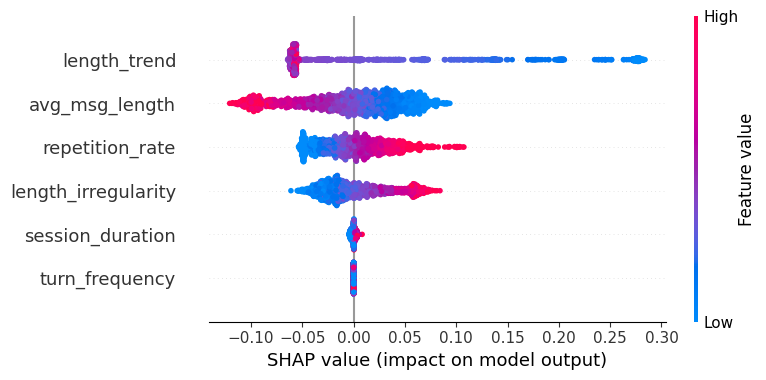

In [ ]:
!pip install shap -q
import shap

explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

# Summary plot
shap.summary_plot(shap_values, X_test, feature_names=feature_cols)

Data loading (DailyDialog + QReCC pulled in)
Feature engineering (static + temporal)
Weak label / proxy fatigue score generation
Random Forest baseline
XGBoost model
LSTM sequence model
Model comparison (RMSE, R², Spearman)

Temporal Consistency Score and Calibration Error

In [ ]:
# --- Temporal Consistency Score ---
# Measures how stable predictions are across consecutive turns within the same session
# (using the LSTM, since it's the only model that sees raw temporal sequences)

def temporal_consistency_score(model, sequences, device):
    model.eval()
    consistency_scores = []
    with torch.no_grad():
        for seq in sequences:
            if len(seq) < 2:
                continue
            # Get predictions at each prefix length (simulating real-time monitoring)
            prefix_preds = []
            for t in range(1, len(seq) + 1):
                prefix = torch.tensor(seq[:t], dtype=torch.float32).unsqueeze(0).to(device)
                length = torch.tensor([t]).to(device)
                pred = model(prefix, length).item()
                prefix_preds.append(pred)
            # Consistency = inverse of variance in successive prediction changes
            diffs = np.diff(prefix_preds)
            consistency_scores.append(np.std(diffs))
    return np.mean(consistency_scores), consistency_scores

avg_instability, all_instabilities = temporal_consistency_score(model, test_seqs, device)
temporal_consistency = 1 / (1 + avg_instability)  # convert instability to a 0-1 consistency score

print(f"Average prediction instability (std of step-to-step diffs): {avg_instability:.4f}")
print(f"Temporal Consistency Score: {temporal_consistency:.4f}")

# --- Calibration Error ---
# Measures whether predicted fatigue scores match actual observed frequencies (binned)

def expected_calibration_error(y_true, y_pred, n_bins=10):
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0
    total = len(y_true)
    for i in range(n_bins):
        mask = (y_pred >= bins[i]) & (y_pred < bins[i+1])
        if mask.sum() == 0:
            continue
        bin_pred_avg = y_pred[mask].mean()
        bin_true_avg = y_true[mask].mean()
        ece += (mask.sum() / total) * abs(bin_pred_avg - bin_true_avg)
    return ece

ece_lstm = expected_calibration_error(all_labels, all_preds)
print(f"\nLSTM Expected Calibration Error: {ece_lstm:.4f}")

Average prediction instability (std of step-to-step diffs): 0.0568
Temporal Consistency Score: 0.9463

LSTM Expected Calibration Error: 0.0083


In [ ]:
from sklearn.metrics import roc_auc_score, f1_score

threshold = np.median(all_labels)  # or use a fixed 0.3/0.5 cutoff
y_true_binary = (all_labels > threshold).astype(int)
y_pred_binary = (all_preds > threshold).astype(int)

auc = roc_auc_score(y_true_binary, all_preds)
f1 = f1_score(y_true_binary, y_pred_binary)

print(f"AUC-ROC (thresholded): {auc:.4f}")
print(f"F1-Score (thresholded): {f1:.4f}")

AUC-ROC (thresholded): 0.9457
F1-Score (thresholded): 0.8385


In [ ]:
# ============================================================
# Extend to QReCC: build conversations from Conversation_no/Turn_no,
# extract features the same way as DailyDialog, and merge sources.
# ============================================================

import pandas as pd
import numpy as np

def build_qrecc_conversations(qrecc_split):
    """Group QReCC rows into ordered conversations (human=Question, gpt=Answer)."""
    df = pd.DataFrame(qrecc_split)
    conversations = []
    for conv_id, group in df.groupby("Conversation_no"):
        group = group.sort_values("Turn_no")
        turns = []
        for _, row in group.iterrows():
            q = str(row["Question"]).strip()
            a = str(row["Answer"]).strip()
            if q:
                turns.append({"from": "human", "value": q})
            if a:
                turns.append({"from": "gpt", "value": a})
        if len(turns) >= 4:  # need at least 2 human turns
            conversations.append(turns)
    return conversations

qrecc_conversations = build_qrecc_conversations(qrecc_train)
print(f"Built {len(qrecc_conversations)} QReCC conversations")

# Reuse your existing extract_session_features function
qrecc_features_list = []
for conv in qrecc_conversations:
    feats = extract_session_features(conv)
    if feats:
        qrecc_features_list.append(feats)

df_qrecc_features = pd.DataFrame(qrecc_features_list)
print(f"Extracted features from {len(df_qrecc_features)} QReCC sessions")

# Tag source before merging
df_features["source"] = "DailyDialog"
df_qrecc_features["source"] = "QReCC"

# Unified interaction log (this is the "Dataset merge" step from your diagram)
df_merged = pd.concat([df_features, df_qrecc_features], ignore_index=True)
print(f"\nMerged dataset: {len(df_merged)} total sessions")
print(df_merged["source"].value_counts())
df_merged.head()

Built 9689 QReCC conversations
Extracted features from 9689 QReCC sessions

Merged dataset: 19938 total sessions
source
DailyDialog    10249
QReCC           9689
Name: count, dtype: int64


,session_duration,avg_msg_length,turn_frequency,length_trend,length_irregularity,repetition_rate,fatigue_score,source
0,10,15.200000,5,0.6,6.881860,0.130435,0.227402,DailyDialog
1,6,8.166667,3,-1.0,3.399346,0.000000,0.298490,DailyDialog
2,4,5.750000,2,-3.0,1.500000,0.090909,0.482614,DailyDialog
3,4,7.000000,2,1.0,0.500000,0.000000,0.202500,DailyDialog
4,8,12.000000,4,-1.0,2.915476,0.000000,0.233732,DailyDialog


In [ ]:
df_merged["fatigue_score"] = df_merged.apply(compute_fatigue_score, axis=1)

print(df_merged.groupby("source")[
    ["avg_msg_length", "length_trend", "repetition_rate", "length_irregularity", "fatigue_score"]
].describe().T)

source                      DailyDialog         QReCC
avg_msg_length      count  10249.000000  9.689000e+03
                    mean      11.890539  1.227799e+01
                    std        6.583574  2.349896e+00
                    min        2.500000  2.400000e+00
                    25%        8.000000  1.075000e+01
                    50%       10.500000  1.240000e+01
                    75%       14.000000  1.390000e+01
                    max      154.166667  2.025000e+01
length_trend        count  10249.000000  9.689000e+03
                    mean       0.960604 -5.212209e-02
                    std        6.140304  6.448774e-01
                    min      -76.000000 -7.000000e+00
                    25%       -1.000000 -4.000000e-01
                    50%        0.500000 -3.098798e-17
                    75%        2.500000  3.000000e-01
                    max      152.600000  6.000000e+00
repetition_rate     count  10249.000000  9.689000e+03
                    mean    

In [ ]:
# ============================================================
# Retrain on merged multi-source dataset
# ============================================================
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

df_model = pd.get_dummies(df_merged, columns=["source"], drop_first=True)

feature_cols_merged = ["session_duration", "avg_msg_length", "turn_frequency",
                        "length_trend", "length_irregularity", "repetition_rate"] + \
                       [c for c in df_model.columns if c.startswith("source_")]

X_m = df_model[feature_cols_merged]
y_m = df_model["fatigue_score"]

X_train_m, X_test_m, y_train_m, y_test_m, src_train, src_test = train_test_split(
    X_m, y_m, df_merged["source"], test_size=0.2, random_state=42, stratify=df_merged["source"]
)

rf_merged = RandomForestRegressor(n_estimators=200, max_depth=8, random_state=42)
rf_merged.fit(X_train_m, y_train_m)
pred_rf_m = rf_merged.predict(X_test_m)

print("=== Random Forest (merged) — overall ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_m, pred_rf_m)):.4f}")
print(f"R²: {r2_score(y_test_m, pred_rf_m):.4f}")
print(f"Spearman: {spearmanr(y_test_m, pred_rf_m)[0]:.4f}")

results_df = pd.DataFrame({"y_true": y_test_m, "y_pred": pred_rf_m, "source": src_test.values})
print("\n=== Per-source performance ===")
for src in results_df["source"].unique():
    sub = results_df[results_df["source"] == src]
    rmse_s = np.sqrt(mean_squared_error(sub["y_true"], sub["y_pred"]))
    r2_s = r2_score(sub["y_true"], sub["y_pred"])
    print(f"{src}: RMSE={rmse_s:.4f}, R²={r2_s:.4f}, n={len(sub)}")

=== Random Forest (merged) — overall ===
RMSE: 0.0176
R²: 0.9610
Spearman: 0.9664

=== Per-source performance ===
QReCC: RMSE=0.0155, R²=0.9255, n=1938
DailyDialog: RMSE=0.0195, R²=0.9685, n=2050


In [ ]:
# ============================================================
# XGBoost on merged multi-source dataset
# ============================================================
from xgboost import XGBRegressor

xgb_merged = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42)
xgb_merged.fit(X_train_m, y_train_m)
pred_xgb_m = xgb_merged.predict(X_test_m)

print("=== XGBoost (merged) — overall ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test_m, pred_xgb_m)):.4f}")
print(f"R²: {r2_score(y_test_m, pred_xgb_m):.4f}")
print(f"Spearman: {spearmanr(y_test_m, pred_xgb_m)[0]:.4f}")

results_df_xgb = pd.DataFrame({"y_true": y_test_m, "y_pred": pred_xgb_m, "source": src_test.values})
print("\n=== Per-source performance (XGBoost) ===")
for src in results_df_xgb["source"].unique():
    sub = results_df_xgb[results_df_xgb["source"] == src]
    rmse_s = np.sqrt(mean_squared_error(sub["y_true"], sub["y_pred"]))
    r2_s = r2_score(sub["y_true"], sub["y_pred"])
    print(f"{src}: RMSE={rmse_s:.4f}, R²={r2_s:.4f}, n={len(sub)}")

# Feature importance on merged data
importance_df_merged = pd.DataFrame({
    "feature": feature_cols_merged,
    "importance": xgb_merged.feature_importances_
}).sort_values("importance", ascending=False)
print("\nXGBoost Feature Importances (merged):")
print(importance_df_merged)


=== XGBoost (merged) — overall ===
RMSE: 0.0047
R²: 0.9972
Spearman: 0.9984

=== Per-source performance (XGBoost) ===
QReCC: RMSE=0.0036, R²=0.9960, n=1938
DailyDialog: RMSE=0.0056, R²=0.9974, n=2050

XGBoost Feature Importances (merged):
               feature  importance
3         length_trend    0.726706
5      repetition_rate    0.099543
1       avg_msg_length    0.099047
4  length_irregularity    0.067676
2       turn_frequency    0.005383
0     session_duration    0.001048
6         source_QReCC    0.000596


In [ ]:
# ============================================================
# Build merged sequence dataset (DailyDialog + QReCC) for LSTM
# ============================================================

sequences_merged = []
labels_merged = []
sources_merged = []

# DailyDialog sequences (reuse existing dd loop)
for conv in dd["train"]:
    seq = extract_sequence_features(conv["conversations"])
    if seq and len(seq) >= 2:
        feats = extract_session_features(conv["conversations"])
        if feats:
            label = compute_fatigue_score(pd.Series(feats))
            sequences_merged.append(seq)
            labels_merged.append(label)
            sources_merged.append("DailyDialog")

# QReCC sequences (reuse qrecc_conversations built earlier)
for conv in qrecc_conversations:
    seq = extract_sequence_features(conv)
    if seq and len(seq) >= 2:
        feats = extract_session_features(conv)
        if feats:
            label = compute_fatigue_score(pd.Series(feats))
            sequences_merged.append(seq)
            labels_merged.append(label)
            sources_merged.append("QReCC")

print(f"Total merged sequences: {len(sequences_merged)}")
print(pd.Series(sources_merged).value_counts())

# Train/test split, stratified by source
from sklearn.model_selection import train_test_split
train_seqs_m, test_seqs_m, train_labels_m, test_labels_m, train_src_m, test_src_m = train_test_split(
    sequences_merged, labels_merged, sources_merged,
    test_size=0.2, random_state=42, stratify=sources_merged
)

train_ds_m = FatigueDataset(train_seqs_m, train_labels_m)
test_ds_m = FatigueDataset(test_seqs_m, test_labels_m)

train_loader_m = DataLoader(train_ds_m, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader_m = DataLoader(test_ds_m, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"\nTrain: {len(train_ds_m)}, Test: {len(test_ds_m)}")

Total merged sequences: 19938
DailyDialog    10249
QReCC           9689
Name: count, dtype: int64

Train: 15950, Test: 3988



# Train LSTM on merged multi-source dataset


In [ ]:

import torch
import torch.nn as nn
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model_merged = FatigueLSTM(input_size=3, hidden_size=32, num_layers=1).to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model_merged.parameters(), lr=0.001)

n_epochs = 20
train_losses_m = []
val_losses_m = []

for epoch in range(n_epochs):
    model_merged.train()
    total_loss = 0
    for x_batch, lengths, y_batch in train_loader_m:
        x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)

        optimizer.zero_grad()
        preds = model_merged(x_batch, lengths)
        loss = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x_batch.size(0)

    avg_train_loss = total_loss / len(train_ds_m)
    train_losses_m.append(avg_train_loss)

    model_merged.eval()
    val_loss = 0
    with torch.no_grad():
        for x_batch, lengths, y_batch in test_loader_m:
            x_batch, lengths, y_batch = x_batch.to(device), lengths.to(device), y_batch.to(device)
            preds = model_merged(x_batch, lengths)
            loss = criterion(preds, y_batch)
            val_loss += loss.item() * x_batch.size(0)
    avg_val_loss = val_loss / len(test_ds_m)
    val_losses_m.append(avg_val_loss)

    print(f"Epoch {epoch+1}/{n_epochs} - Train Loss: {avg_train_loss:.5f} - Val Loss: {avg_val_loss:.5f}")

Using device: cpu
Epoch 1/20 - Train Loss: 0.00745 - Val Loss: 0.00347
Epoch 2/20 - Train Loss: 0.00297 - Val Loss: 0.00251
Epoch 3/20 - Train Loss: 0.00247 - Val Loss: 0.00228
Epoch 4/20 - Train Loss: 0.00223 - Val Loss: 0.00210
Epoch 5/20 - Train Loss: 0.00209 - Val Loss: 0.00239
Epoch 6/20 - Train Loss: 0.00198 - Val Loss: 0.00192
Epoch 7/20 - Train Loss: 0.00191 - Val Loss: 0.00188
Epoch 8/20 - Train Loss: 0.00189 - Val Loss: 0.00195
Epoch 9/20 - Train Loss: 0.00184 - Val Loss: 0.00196
Epoch 10/20 - Train Loss: 0.00181 - Val Loss: 0.00192
Epoch 11/20 - Train Loss: 0.00179 - Val Loss: 0.00189
Epoch 12/20 - Train Loss: 0.00179 - Val Loss: 0.00195
Epoch 13/20 - Train Loss: 0.00176 - Val Loss: 0.00176
Epoch 14/20 - Train Loss: 0.00174 - Val Loss: 0.00174
Epoch 15/20 - Train Loss: 0.00171 - Val Loss: 0.00181
Epoch 16/20 - Train Loss: 0.00171 - Val Loss: 0.00170
Epoch 17/20 - Train Loss: 0.00169 - Val Loss: 0.00169
Epoch 18/20 - Train Loss: 0.00171 - Val Loss: 0.00174
Epoch 19/20 - Train

*** Evaluate merged LSTM — overall and per-source***

In [ ]:



from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import spearmanr

model_merged.eval()
all_preds_m = []
all_labels_m = []

with torch.no_grad():
    for x_batch, lengths, y_batch in test_loader_m:
        x_batch, lengths = x_batch.to(device), lengths.to(device)
        preds = model_merged(x_batch, lengths)
        all_preds_m.extend(preds.cpu().numpy())
        all_labels_m.extend(y_batch.numpy())

all_preds_m = np.array(all_preds_m)
all_labels_m = np.array(all_labels_m)

lstm_rmse_m = np.sqrt(mean_squared_error(all_labels_m, all_preds_m))
lstm_r2_m = r2_score(all_labels_m, all_preds_m)
lstm_spearman_m, _ = spearmanr(all_labels_m, all_preds_m)

print("=== LSTM (merged) — overall ===")
print(f"RMSE: {lstm_rmse_m:.4f}")
print(f"R²: {lstm_r2_m:.4f}")
print(f"Spearman: {lstm_spearman_m:.4f}")

# Per-source breakdown
results_lstm = pd.DataFrame({
    "y_true": all_labels_m, "y_pred": all_preds_m, "source": test_src_m
})
print("\n=== Per-source performance (LSTM) ===")
for src in results_lstm["source"].unique():
    sub = results_lstm[results_lstm["source"] == src]
    rmse_s = np.sqrt(mean_squared_error(sub["y_true"], sub["y_pred"]))
    r2_s = r2_score(sub["y_true"], sub["y_pred"])
    print(f"{src}: RMSE={rmse_s:.4f}, R²={r2_s:.4f}, n={len(sub)}")

=== LSTM (merged) — overall ===
RMSE: 0.0410
R²: 0.7898
Spearman: 0.7933

=== Per-source performance (LSTM) ===
QReCC: RMSE=0.0360, R²=0.5985, n=1938
DailyDialog: RMSE=0.0452, R²=0.8303, n=2050



# Consolidated results table: all models x all sources


In [ ]:


def summarize(df, model_name):
    rows = []
    overall_rmse = np.sqrt(mean_squared_error(df["y_true"], df["y_pred"]))
    overall_r2 = r2_score(df["y_true"], df["y_pred"])
    overall_sp, _ = spearmanr(df["y_true"], df["y_pred"])
    rows.append({"Model": model_name, "Source": "Overall", "RMSE": overall_rmse, "R2": overall_r2, "Spearman": overall_sp, "n": len(df)})
    for src in df["source"].unique():
        sub = df[df["source"] == src]
        rmse_s = np.sqrt(mean_squared_error(sub["y_true"], sub["y_pred"]))
        r2_s = r2_score(sub["y_true"], sub["y_pred"])
        sp_s, _ = spearmanr(sub["y_true"], sub["y_pred"])
        rows.append({"Model": model_name, "Source": src, "RMSE": rmse_s, "R2": r2_s, "Spearman": sp_s, "n": len(sub)})
    return rows

all_rows = []
all_rows += summarize(results_df, "Random Forest")       # from RF merged run
all_rows += summarize(results_df_xgb, "XGBoost")          # from XGB merged run
all_rows += summarize(results_lstm, "LSTM")                # from LSTM merged run

final_comparison = pd.DataFrame(all_rows)
final_comparison = final_comparison.sort_values(["Model", "Source"])
print(final_comparison.to_string(index=False))

# Save for your report
final_comparison.to_csv("model_comparison_merged.csv", index=False)
print("\nSaved to model_comparison_merged.csv")

        Model      Source     RMSE       R2  Spearman    n
         LSTM DailyDialog 0.045173 0.830343  0.854964 2050
         LSTM     Overall 0.040972 0.789787  0.793264 3988
         LSTM       QReCC 0.035998 0.598532  0.758370 1938
Random Forest DailyDialog 0.019459 0.968518  0.972816 2050
Random Forest     Overall 0.017649 0.960992  0.966376 3988
Random Forest       QReCC 0.015507 0.925501  0.960472 1938
      XGBoost DailyDialog 0.005586 0.997406  0.998556 2050
      XGBoost     Overall 0.004727 0.997202  0.998366 3988
      XGBoost       QReCC 0.003602 0.995980  0.998132 1938

Saved to model_comparison_merged.csv



# SHAP interpretability on merged XGBoost model


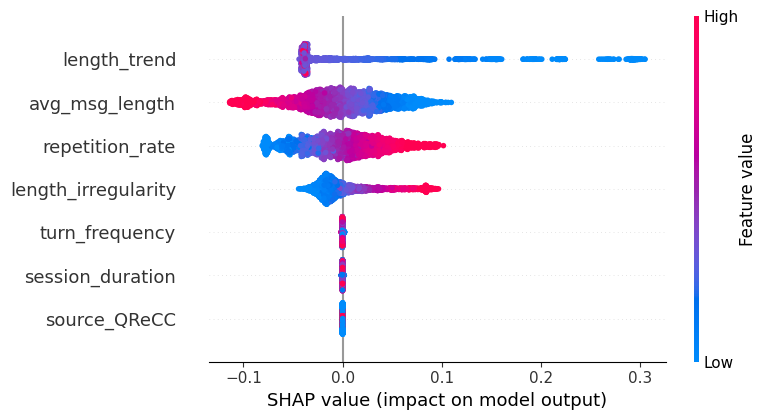

In [ ]:

import shap

explainer_merged = shap.TreeExplainer(xgb_merged)
shap_values_merged = explainer_merged.shap_values(X_test_m)

# Overall summary plot
shap.summary_plot(shap_values_merged, X_test_m, feature_names=feature_cols_merged)

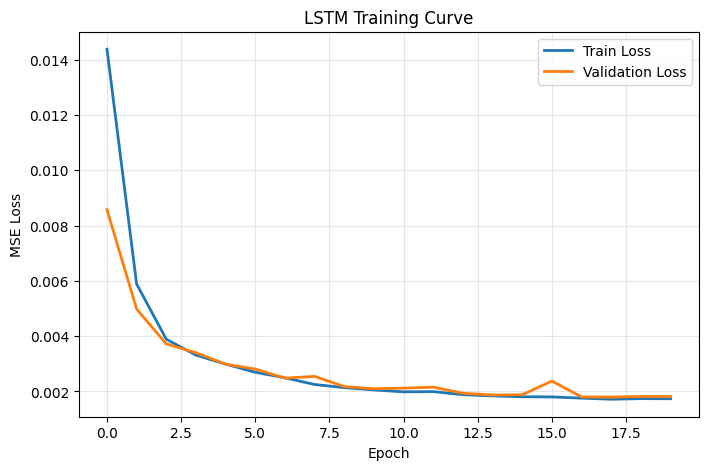

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_losses, label="Train Loss", linewidth=2)
plt.plot(val_losses, label="Validation Loss", linewidth=2)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("LSTM Training Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()

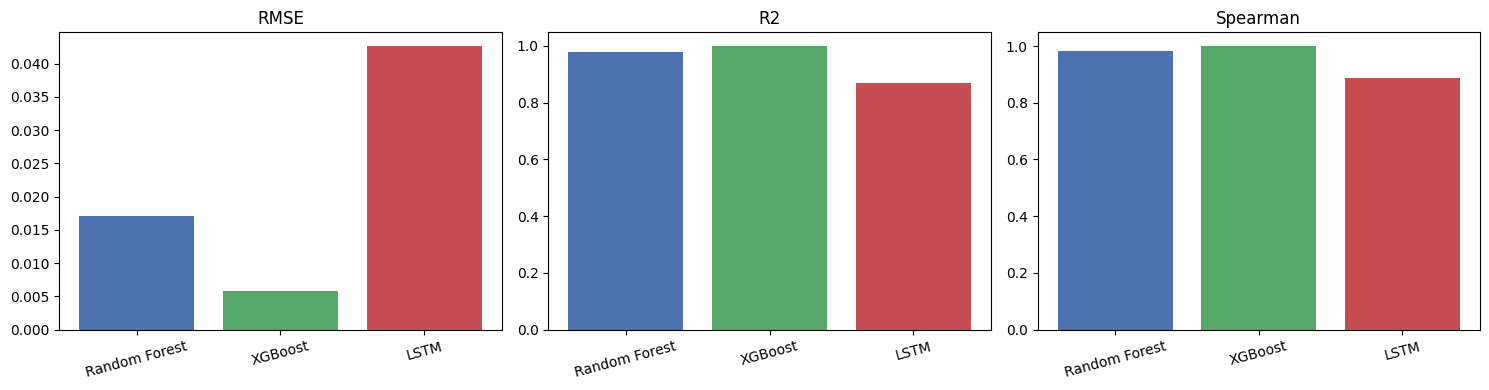

In [ ]:
comparison = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost", "LSTM"],
    "RMSE": [rmse, rmse_xgb, lstm_rmse],
    "R2": [r2, r2_xgb, lstm_r2],
    "Spearman": [spearman_corr, spearman_xgb, lstm_spearman]
})

fig, axes = plt.subplots(1, 3, figsize=(15,4))
for ax, metric in zip(axes, ["RMSE", "R2", "Spearman"]):
    ax.bar(comparison["Model"], comparison[metric], color=["#4C72B0","#55A868","#C44E52"])
    ax.set_title(metric)
    ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

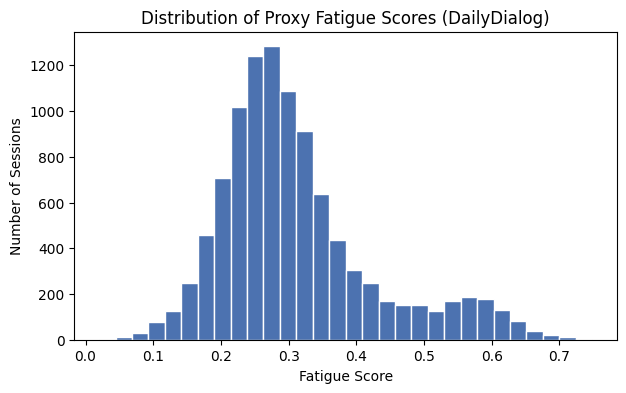

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df_features["fatigue_score"], bins=30, color="#4C72B0", edgecolor="white")
plt.xlabel("Fatigue Score")
plt.ylabel("Number of Sessions")
plt.title("Distribution of Proxy Fatigue Scores (DailyDialog)")
plt.savefig("fatigue_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

KeyError: 'fatigue_score'

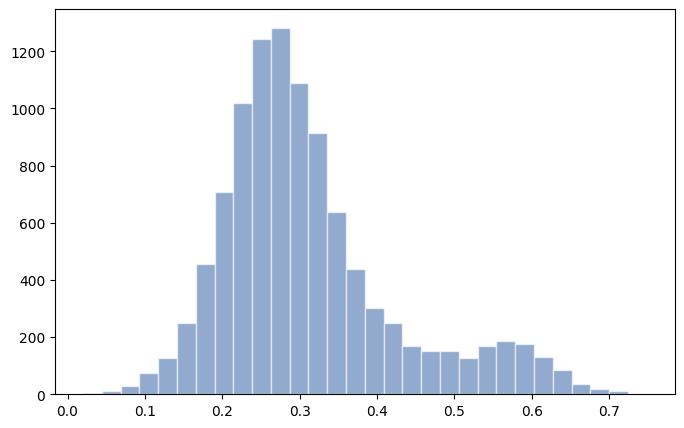

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df_features["fatigue_score"], bins=30, alpha=0.6,
         label="DailyDialog", color="#4C72B0", edgecolor="white")
plt.hist(df_qrecc_features["fatigue_score"], bins=30, alpha=0.6,
         label="QReCC", color="#C44E52", edgecolor="white")
plt.xlabel("Fatigue Score")
plt.ylabel("Number of Sessions")
plt.title("Fatigue Score Distribution: DailyDialog vs QReCC")
plt.legend()
plt.savefig("fatigue_distribution_comparison.png", dpi=150, bbox_inches="tight")
plt.show()